# Econometrics II - Assignment 2
## Geopolitical Risk and Economic Activity

**Implementation Structure**
1. Setup and data loading
2. Graphical analysis
3. VAR lag selection
4. Preferred VAR estimation and diagnostics
5. Granger causality and contemporaneous relationships
6. Orthogonalized impulse responses (GPR-first ordering)
7. Robustness checks (post-9/11 and recent-crisis exclusion)
8. Export tables and figures for report

## 1) Setup and Data Loading

In [14]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.api import VAR
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.stats.stattools import jarque_bera

warnings.filterwarnings("ignore")

# Output folders
os.makedirs("figures", exist_ok=True)
os.makedirs("tables", exist_ok=True)

# Plot style
plt.rcParams.update({
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

def load_assignment2_data(path="Assignment_2.xlsx"):
    """Load assignment data and ensure required transformed series exist."""
    df = pd.read_excel(path)
    df.columns = [str(c).strip() for c in df.columns]

    # Use first column as date index if it looks like dates/time labels
    first_col = df.columns[0]
    if first_col not in ["GPR", "INDPRO", "Mkt", "g", "y", "s"]:
        idx = pd.to_datetime(df[first_col], errors="coerce")
        if idx.notna().mean() > 0.8:
            df = df.drop(columns=[first_col])
            df.index = idx
        else:
            df.index = pd.RangeIndex(start=0, stop=len(df), step=1)

    # If index is not datetime, try common date columns
    if not isinstance(df.index, pd.DatetimeIndex):
        for candidate in ["Date", "date", "DATE", "Month", "month"]:
            if candidate in df.columns:
                idx = pd.to_datetime(df[candidate], errors="coerce")
                if idx.notna().mean() > 0.8:
                    df = df.drop(columns=[candidate])
                    df.index = idx
                    break

    # Ensure transformed variables exist
    if "g" not in df.columns and "GPR" in df.columns:
        df["g"] = np.log(df["GPR"])
    if "y" not in df.columns and "INDPRO" in df.columns:
        df["y"] = np.log(df["INDPRO"]).diff()
    if "s" not in df.columns and "Mkt" in df.columns:
        df["s"] = np.log1p(df["Mkt"] / 100.0)

    required = ["g", "y", "s"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required variables after transformations: {missing}")

    z = df[["g", "s", "y"]].copy()  # ordering for Cholesky: GPR -> Mkt -> INDPRO growth
    n_before_clean = len(z)
    z = z.replace([np.inf, -np.inf], np.nan).dropna()
    dropped_obs = n_before_clean - len(z)

    # Keep monthly timestamp index if possible
    if not isinstance(z.index, pd.DatetimeIndex):
        z.index = pd.date_range(start="1985-01-01", periods=len(z), freq="MS")

    return df, z, dropped_obs

df_raw, z, dropped_obs = load_assignment2_data("Assignment_2.xlsx")
print("Raw columns:", df_raw.columns.tolist())
print("Analysis sample:", z.index.min().date(), "to", z.index.max().date(), "| obs:", len(z))
print("Dropped observations from cleaning:", dropped_obs)
z.head()

Raw columns: ['Unnamed: 0', 'GPR', 'INDPRO', 'Mkt', 'g', 'y', 's']
Analysis sample: 1985-01-01 to 2025-12-01 | obs: 492
Dropped observations from cleaning: 1


,g,s,y
1985-01-01,4.763028,0.017840,0.002747
1985-02-01,4.826552,-0.002102,0.001510
1985-03-01,4.476541,-0.002403,-0.002179
1985-04-01,4.637250,0.055718,0.001453
1985-05-01,5.002469,0.018036,-0.000485


## 2) Graphical Analysis and Summary Statistics

Table: Summary statistics
     mean     std     min     max    skew     kurt
g  4.5673  0.3426  3.6648  6.2394  0.9926   3.3332
s  0.0092  0.0452 -0.2561  0.1275 -1.0403   3.2895
y  0.0013  0.0098 -0.1414  0.0635 -6.2324  96.6242


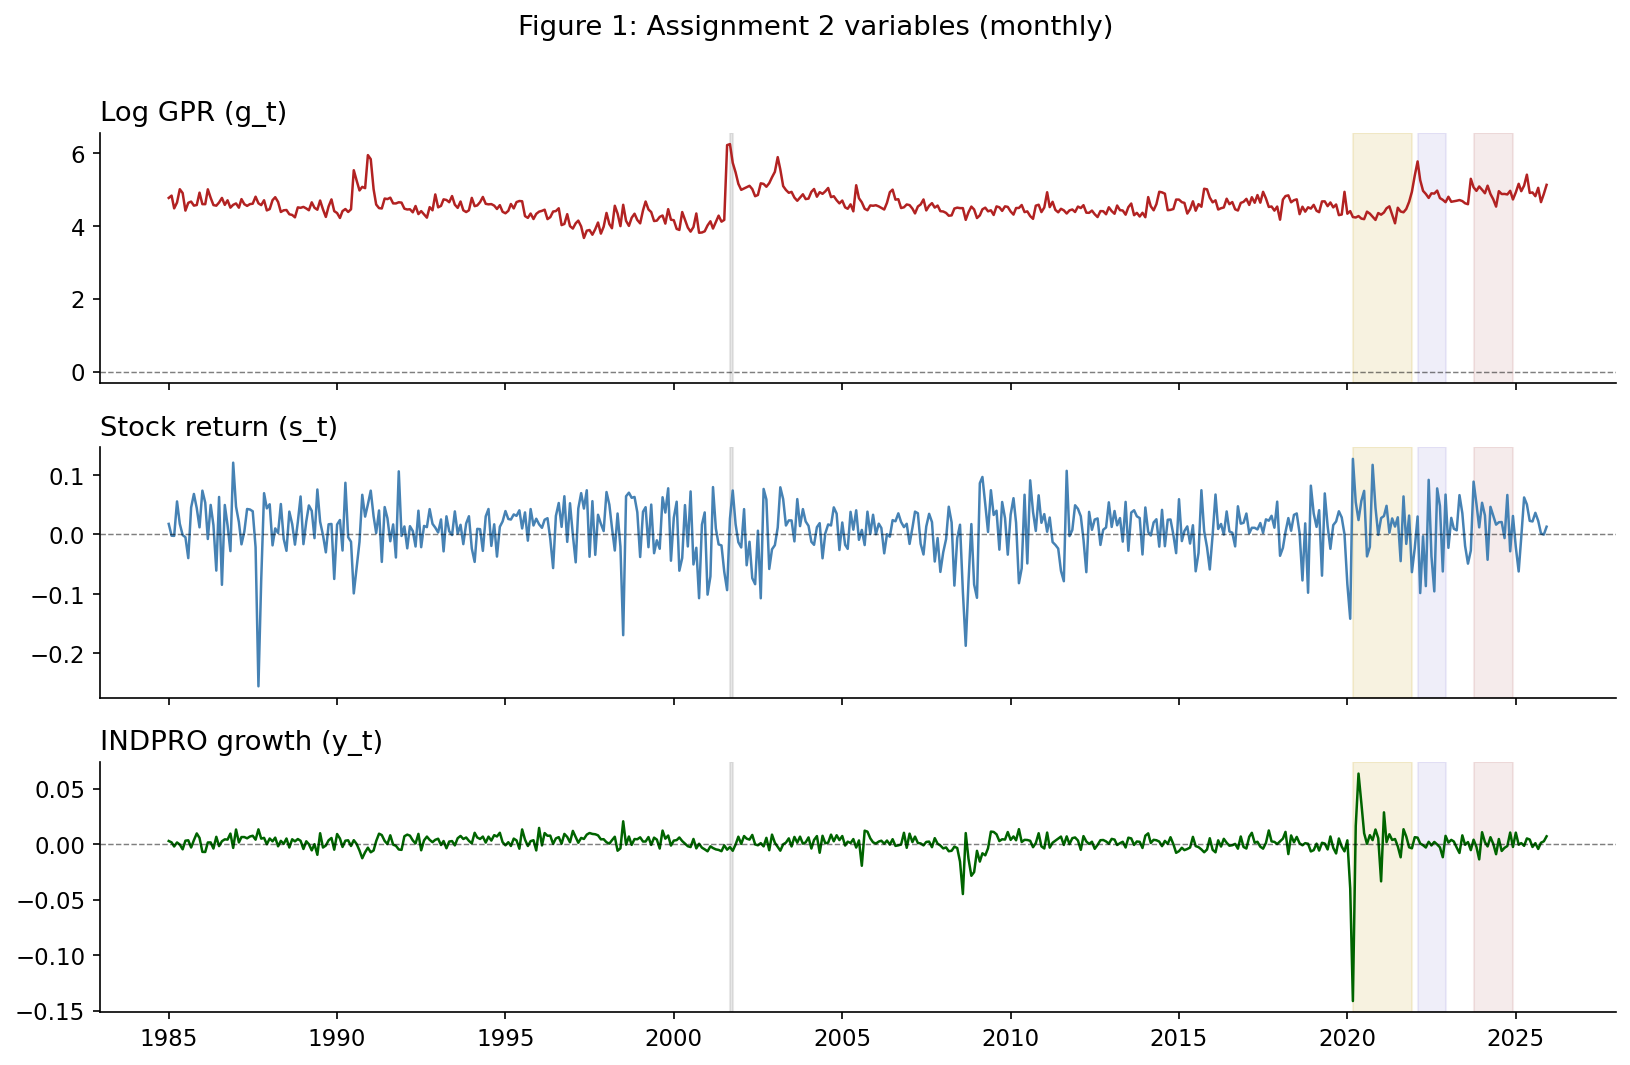

In [15]:
# Summary statistics (for internal checks)
desc = z.describe().T
desc["skew"] = z.skew()
desc["kurt"] = z.kurtosis()
desc = desc[["mean", "std", "min", "max", "skew", "kurt"]].round(4)
print("Table: Summary statistics")
print(desc.to_string())

# Figure 1: Three-panel time-series with key event shading
fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
series_meta = [
    ("g", "Log GPR (g_t)", "firebrick"),
    ("s", "Stock return (s_t)", "steelblue"),
    ("y", "INDPRO growth (y_t)", "darkgreen"),
]

events = [
    ("2001-09-01", "2001-10-01", "9/11", "#888888", 0.18),
    ("2020-03-01", "2021-12-01", "COVID", "#c49a00", 0.12),
    ("2022-02-01", "2022-12-01", "Ukraine", "#6a5acd", 0.10),
    ("2023-10-01", "2024-12-01", "Middle East", "#8b0000", 0.08),
]

for ax, (col, title, color) in zip(axes, series_meta):
    ax.plot(z.index, z[col], color=color, linewidth=1.2)
    ax.set_title(title, loc="left")
    ax.axhline(0, color="black", linewidth=0.7, linestyle="--", alpha=0.5)
    for start, end, _, shade_color, alpha in events:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color=shade_color, alpha=alpha)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.suptitle("Figure 1: Assignment 2 variables (monthly)", y=1.01)
plt.tight_layout()
plt.savefig("figures/fig1_series_panel.pdf", bbox_inches="tight")
plt.show()

## 3) VAR Lag Selection

In [16]:
# Estimate VAR(k) for k=1..4 and compare information criteria
lag_rows = []
fitted = {}
var_model = VAR(z)

for k in range(1, 5):
    res = var_model.fit(k, trend="c")
    fitted[k] = res
    lag_rows.append({
        "Lag": k,
        "AIC": res.aic,
        "BIC": res.bic,
        "HQIC": res.hqic,
        "FPE": res.fpe,
    })

lag_table = pd.DataFrame(lag_rows).set_index("Lag")
preferred_lag = int(lag_table["BIC"].idxmin())
preferred = fitted[preferred_lag]

print("Table: Lag-order comparison")
print(lag_table.round(4).to_string())
print(f"\nPreferred lag by BIC: VAR({preferred_lag})")

Table: Lag-order comparison
         AIC      BIC     HQIC  FPE
Lag                                
1   -18.5525 -18.4499 -18.5122  0.0
2   -18.5615 -18.3818 -18.4910  0.0
3   -18.5772 -18.3200 -18.4762  0.0
4   -18.5483 -18.2134 -18.4167  0.0

Preferred lag by BIC: VAR(1)


## 4) Preferred VAR: Estimation and Diagnostics

In [17]:
print(preferred.summary())

# Stability check
stable = preferred.is_stable(verbose=False)
roots = preferred.roots
min_root_abs = float(np.min(np.abs(roots)))
print(f"Stable VAR: {stable}")
print(f"Minimum absolute root: {min_root_abs:.4f} (stable if > 1)")

# Residual covariance / correlation
resid_cov = preferred.sigma_u
resid_corr = pd.DataFrame(
    np.corrcoef(preferred.resid.T),
    index=preferred.names,
    columns=preferred.names,
 )
print("\nResidual covariance matrix:")
print(pd.DataFrame(resid_cov, index=preferred.names, columns=preferred.names).round(6).to_string())
print("\nResidual correlation matrix:")
print(resid_corr.round(4).to_string())

# Misspecification tests by equation
diag_rows = []
for col in preferred.resid.columns:
    r = preferred.resid[col].dropna()

    lb = acorr_ljungbox(r, lags=[12], return_df=True)
    lb_stat = float(lb["lb_stat"].iloc[-1])
    lb_p = float(lb["lb_pvalue"].iloc[-1])

    arch_stat, arch_p, _, _ = het_arch(r, nlags=4)
    jb_stat, jb_p, _, _ = jarque_bera(r)

    diag_rows.append({
        "Equation": col,
        "Ljung-Box(12) stat": lb_stat,
        "Ljung-Box(12) p": lb_p,
        "ARCH-LM(4) stat": arch_stat,
        "ARCH-LM(4) p": arch_p,
        "Jarque-Bera stat": jb_stat,
        "Jarque-Bera p": jb_p,
    })

diag_table = pd.DataFrame(diag_rows).set_index("Equation").round(4)
print("\nTable: Diagnostics by equation")
print(diag_table.to_string())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 27, Mar, 2026
Time:                     11:39:30
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -18.4499
Nobs:                     491.000    HQIC:                  -18.5122
Log likelihood:           2476.54    FPE:                8.76525e-09
AIC:                     -18.5525    Det(Omega_mle):     8.55447e-09
--------------------------------------------------------------------
Results for equation g
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const         1.041926         0.132758            7.848           0.000
L1.g          0.772353         0.028950           26.679           0.000
L1.s         -0.175246         0.218842           -0.801           0.423
L1.y         -0.091117 

## 5) Granger Causality and Contemporaneous Relationship

In [18]:
# Targeted Granger-causality tests
tests = [
    ("s", ["g"], "g -> s"),
    ("y", ["g"], "g -> y"),
    ("g", ["s"], "s -> g"),
    ("g", ["y"], "y -> g"),
    ("y", ["s"], "s -> y"),
    ("s", ["y"], "y -> s"),
]

caus_rows = []
for caused, causing, label in tests:
    out = preferred.test_causality(caused=caused, causing=causing, kind="wald")
    stat = float(np.squeeze(out.test_statistic))
    pval = float(np.squeeze(out.pvalue))
    caus_rows.append({
        "Direction": label,
        "Statistic": stat,
        "p-value": pval,
        "Reject 5%": "Yes" if pval < 0.05 else "No",
    })

caus_table = pd.DataFrame(caus_rows).set_index("Direction")
print("Table: Granger-causality tests (Wald)")
print(caus_table.round(4).to_string())

print("\nContemporaneous relationship is assessed through residual correlations (above),")
print("while Granger tests capture predictive precedence from lags only.")

Table: Granger-causality tests (Wald)
           Statistic  p-value Reject 5%
Direction                              
g -> s        0.5036   0.4779        No
g -> y        1.3324   0.2484        No
s -> g        0.6413   0.4233        No
y -> g        0.0081   0.9282        No
s -> y       20.5118   0.0000       Yes
y -> s        0.8679   0.3515        No

Contemporaneous relationship is assessed through residual correlations (above),
while Granger tests capture predictive precedence from lags only.


In [19]:
import statsmodels.api as sm

# Build VAR(1) regression design used by preferred model
tmp = z.copy()
tmp["g_l1"] = tmp["g"].shift(1)
tmp["s_l1"] = tmp["s"].shift(1)
tmp["y_l1"] = tmp["y"].shift(1)
reg_df = tmp.dropna().copy()

X = sm.add_constant(reg_df[["g_l1", "s_l1", "y_l1"]])

# HAC lag choice for monthly data: 12 lags (one annual cycle)
hac_lags = 12

# s-equation and y-equation with HAC covariance
ols_s = sm.OLS(reg_df["s"], X).fit(cov_type="HAC", cov_kwds={"maxlags": hac_lags})
ols_y = sm.OLS(reg_df["y"], X).fit(cov_type="HAC", cov_kwds={"maxlags": hac_lags})

def scalar_wald(result, restriction):
    w = result.wald_test(restriction)
    stat = float(np.squeeze(w.statistic))
    pval = float(np.squeeze(w.pvalue))
    return stat, pval

robust_rows = []

# H0: g_l1 = 0 in s equation
stat, pval = scalar_wald(ols_s, "g_l1 = 0")
robust_rows.append({
    "Restriction": "g -> s (HAC)",
    "Wald stat": stat,
    "p-value": pval,
    "Reject 5%": "Yes" if pval < 0.05 else "No",
})

# H0: g_l1 = 0 in y equation
stat, pval = scalar_wald(ols_y, "g_l1 = 0")
robust_rows.append({
    "Restriction": "g -> y (HAC)",
    "Wald stat": stat,
    "p-value": pval,
    "Reject 5%": "Yes" if pval < 0.05 else "No",
})

# H0: s_l1 = 0 in y equation
stat, pval = scalar_wald(ols_y, "s_l1 = 0")
robust_rows.append({
    "Restriction": "s -> y (HAC)",
    "Wald stat": stat,
    "p-value": pval,
    "Reject 5%": "Yes" if pval < 0.05 else "No",
})

robust_caus_table = pd.DataFrame(robust_rows).set_index("Restriction").round(4)
print("Table: HAC-robust Wald tests for key predictive restrictions")
print(robust_caus_table.to_string())

Table: HAC-robust Wald tests for key predictive restrictions
              Wald stat  p-value Reject 5%
Restriction                               
g -> s (HAC)     0.3395   0.5601        No
g -> y (HAC)     1.8690   0.1716        No
s -> y (HAC)     1.9619   0.1613        No


### 5b) Robust Inference for Key Predictive Restrictions (HAC)
Because residual diagnostics indicate heteroskedasticity/non-normality, we also report HAC-robust Wald tests in equation-by-equation regressions of the preferred VAR(1).

## 6) Orthogonalized Impulse Responses (GPR-first)

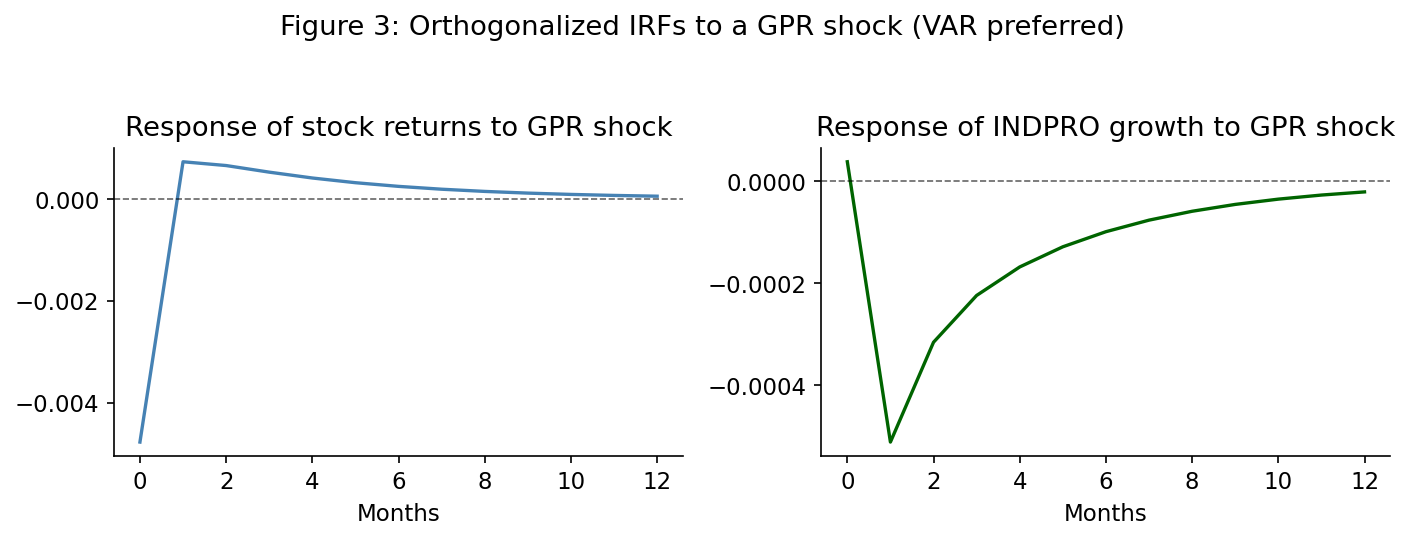

Table: Key orthogonalized responses to GPR shock
    IRF s <- g shock  IRF y <- g shock
h                                     
0           -0.00478           0.00004
1            0.00073          -0.00051
2            0.00065          -0.00032
3            0.00052          -0.00022
4            0.00041          -0.00017
5            0.00032          -0.00013
6            0.00024          -0.00010
7            0.00019          -0.00008
8            0.00015          -0.00006
9            0.00011          -0.00005
10           0.00009          -0.00004
11           0.00007          -0.00003
12           0.00005          -0.00002


In [26]:
# Orthogonalized IRFs from Cholesky ordering: [g, s, y]
horizon = 12
irf = preferred.irf(horizon)

# Keep only actively used responses in report: s <- g and y <- g
resp_s_to_g = irf.orth_irfs[:, 1, 0]
resp_y_to_g = irf.orth_irfs[:, 2, 0]
h = np.arange(horizon + 1)

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.4), sharex=True)

axes[0].plot(h, resp_s_to_g, color="steelblue", linewidth=1.6)
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.6)
axes[0].set_title("Response of stock returns to GPR shock")
axes[0].set_xlabel("Months")

axes[1].plot(h, resp_y_to_g, color="darkgreen", linewidth=1.6)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.6)
axes[1].set_title("Response of INDPRO growth to GPR shock")
axes[1].set_xlabel("Months")

fig.suptitle("Figure 3: Orthogonalized IRFs to a GPR shock (VAR preferred)", y=1.05)
plt.tight_layout()
plt.savefig("figures/fig3_irf_orth.pdf", bbox_inches="tight")
plt.show()

irf_focus = pd.DataFrame({
    "h": h,
    "IRF s <- g shock": resp_s_to_g,
    "IRF y <- g shock": resp_y_to_g,
}).set_index("h")
print("Table: Key orthogonalized responses to GPR shock")
print(irf_focus.round(5).to_string())

## 7) Robustness: Post-9/11 and Recent-Crisis Exclusion

Table: Robustness comparison (key conclusions)
                    g->s p   g->y p  IRF s<-g h0  IRF s<-g h3  IRF y<-g h0  IRF y<-g h6
Full sample        0.47794  0.24838     -0.00478      0.00052      0.00004     -0.00010
Post-9/11          0.91717  0.81677     -0.00297      0.00010      0.00001      0.00004
Exclude 2020-2024  0.14003  0.09657     -0.00430      0.00096     -0.00017     -0.00010


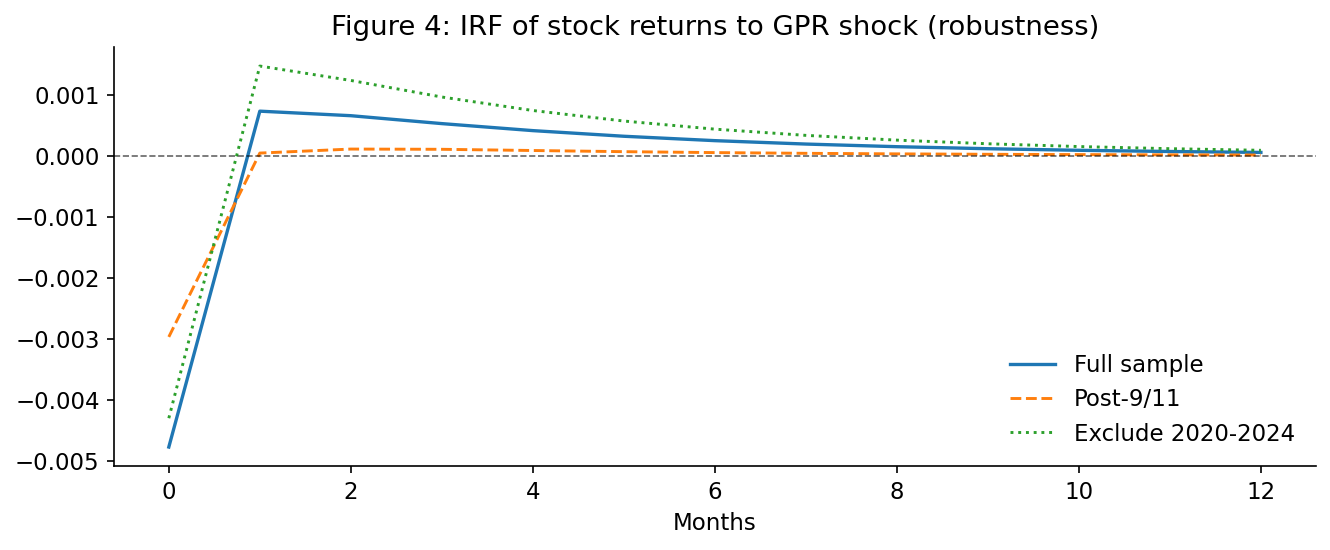

In [25]:
def fit_same_lag(sample_df, lag):
    return VAR(sample_df).fit(lag, trend="c")

# Robustness sample A: post-9/11
z_post911 = z.loc[z.index >= pd.Timestamp("2001-09-01")].copy()
rob_post911 = fit_same_lag(z_post911, preferred_lag)

# Robustness sample B: exclude Jan 2020-Dec 2024
mask_excl = (z.index >= pd.Timestamp("2020-01-01")) & (z.index <= pd.Timestamp("2024-12-31"))
z_excl_recent = z.loc[~mask_excl].copy()
rob_excl_recent = fit_same_lag(z_excl_recent, preferred_lag)

def extract_key_results(model_res):
    t1 = model_res.test_causality(caused="s", causing=["g"], kind="wald")
    t2 = model_res.test_causality(caused="y", causing=["g"], kind="wald")
    irf_local = model_res.irf(12)
    return {
        "g->s p": float(np.squeeze(t1.pvalue)),
        "g->y p": float(np.squeeze(t2.pvalue)),
        "IRF s<-g h0": float(irf_local.orth_irfs[0, 1, 0]),
        "IRF s<-g h3": float(irf_local.orth_irfs[3, 1, 0]),
        "IRF y<-g h0": float(irf_local.orth_irfs[0, 2, 0]),
        "IRF y<-g h6": float(irf_local.orth_irfs[6, 2, 0]),
    }

robust_table = pd.DataFrame({
    "Full sample": extract_key_results(preferred),
    "Post-9/11": extract_key_results(rob_post911),
    "Exclude 2020-2024": extract_key_results(rob_excl_recent),
}).T.round(5)

print("Table: Robustness comparison (key conclusions)")
print(robust_table.to_string())

# Figure 4: Compare response of s_t to a g shock across samples
h = np.arange(13)
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(h, preferred.irf(12).orth_irfs[:, 1, 0], label="Full sample", linewidth=1.6)
ax.plot(h, rob_post911.irf(12).orth_irfs[:, 1, 0], label="Post-9/11", linewidth=1.4, linestyle="--")
ax.plot(h, rob_excl_recent.irf(12).orth_irfs[:, 1, 0], label="Exclude 2020-2024", linewidth=1.4, linestyle=":")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.6)
ax.set_title("Figure 4: IRF of stock returns to GPR shock (robustness)")
ax.set_xlabel("Months")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("figures/fig4_irf_robustness.pdf", bbox_inches="tight")
plt.show()

## 8) Export Tables for LaTeX

In [22]:
# Export key tables as LaTeX snippets for assignment2.tex
lag_table.round(4).to_latex(
    "tables/table1_lag_selection.tex",
    caption="VAR lag-order selection.",
    label="tab:lag_selection",
    index_names=False,
    float_format="%.4f",
)
diag_table.round(4).to_latex(
    "tables/table2_diagnostics.tex",
    caption="Misspecification diagnostics by equation for preferred VAR.",
    label="tab:diagnostics",
    index_names=False,
    float_format="%.4f",
)
caus_table.round(4).to_latex(
    "tables/table3_granger.tex",
    caption="Granger-causality tests (Wald) in preferred VAR.",
    label="tab:granger",
    index_names=False,
    float_format="%.4f",
)
irf_focus.round(5).to_latex(
    "tables/table4_irf_focus.tex",
    caption="Orthogonalized impulse responses to a GPR shock.",
    label="tab:irf_focus",
    index_names=False,
    float_format="%.5f",
)
robust_table.round(5).to_latex(
    "tables/table5_robustness.tex",
    caption="Robustness comparison across samples.",
    label="tab:robustness",
    index_names=False,
    float_format="%.5f",
)

print("Exported tables to Assignment2/tables/")
print("Saved figures to Assignment2/figures/")

Exported tables to Assignment2/tables/
Saved figures to Assignment2/figures/


In [23]:
# Additional export: HAC-robust restriction tests
robust_caus_table.to_latex(
    "tables/table6_granger_hac.tex",
    caption="HAC-robust Wald tests for key predictive restrictions.",
    label="tab:granger_hac",
    index_names=False,
    float_format="%.4f",
)
print("Exported: tables/table6_granger_hac.tex")

Exported: tables/table6_granger_hac.tex


In [24]:
# Compact output tables for 2-page appendix
diag_compact = diag_table[["Ljung-Box(12) p", "ARCH-LM(4) p", "Jarque-Bera p"]].copy()
diag_compact.columns = ["LB p", "ARCH p", "JB p"]
diag_compact["Any reject (5%)"] = np.where((diag_compact[["LB p", "ARCH p", "JB p"]] < 0.05).any(axis=1), "Yes", "No")

# Keep only restrictions reported in the final appendix table
key_dirs = ["g -> s", "g -> y", "s -> y"]
caus_compact = caus_table.loc[key_dirs, ["p-value"]].rename(columns={"p-value": "Baseline p"}).copy()
hac_map = {
    "g -> s": robust_caus_table.loc["g -> s (HAC)", "p-value"],
    "g -> y": robust_caus_table.loc["g -> y (HAC)", "p-value"],
    "s -> y": robust_caus_table.loc["s -> y (HAC)", "p-value"],
}
caus_compact["HAC p"] = caus_compact.index.map(lambda x: hac_map[x])
caus_compact["Baseline reject 5%"] = np.where(caus_compact["Baseline p"] < 0.05, "Yes", "No")
caus_compact["HAC reject 5%"] = np.where(caus_compact["HAC p"] < 0.05, "Yes", "No")

diag_compact = diag_compact.round(4)
caus_compact = caus_compact.round(4)

diag_compact.to_latex(
    "tables/table7_diag_compact.tex",
    caption="Compact misspecification diagnostics (p-values) for preferred VAR(1).",
    label="tab:diag_compact",
    index_names=False,
    float_format="%.4f",
)
caus_compact.to_latex(
    "tables/table8_causality_compact.tex",
    caption="Baseline versus HAC p-values for key predictive restrictions.",
    label="tab:caus_compact",
    index_names=False,
    float_format="%.4f",
)

print("Exported: tables/table7_diag_compact.tex")
print("Exported: tables/table8_causality_compact.tex")

Exported: tables/table7_diag_compact.tex
Exported: tables/table8_causality_compact.tex
